In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv("C://Users//lenovo 2020//marketing_campaign.csv", delimiter=';')

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [4]:
data = data.dropna()

In [5]:
data.isnull().sum().sum()

0

In [6]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

In [7]:
data['Age'] = 2015 - data['Year_Birth']

In [8]:
data['Spent'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']

In [9]:
data['Living_With'] = data['Marital_Status'].replace({'Married':'Partner', 'Together':'Partner', 'Absurd':'Alone', 'Widow':'Alone', 'YOLO':'Alone', 'Divorced':'Alone', 'Single':'Alone'})

In [10]:
data['Children'] = data['Kidhome'] + data['Teenhome']

In [11]:
data['Family_Size'] = data['Living_With'].replace({'Alone': 1, 'Partner':2}) + data['Children']

C:\Users\lenovo 2020\AppData\Local\Temp\ipykernel_18612\1609205446.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Family_Size'] = data['Living_With'].replace({'Alone': 1, 'Partner':2}) + data['Children']


In [12]:
data['Is_Parent'] = np.where(data.Children > 0, 1, 0)

In [13]:
data['Education'] = data['Education'].replace({'Basic':'Undergraduate', '2n Cycle':'Undergraduate', 'Graduation':'Graduate', 'Master':'Postgraduate', 'PhD':'Postgraduate'})

In [14]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,1617,Alone,0,1,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,27,Alone,2,3,1
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,776,Partner,0,2,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,53,Partner,1,3,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,422,Partner,1,3,1


In [15]:
# Select relevant columns
data = data[['Family_Size', 'Age', 'Children', 'Income', 'Spent', 'Is_Parent']]


In [16]:
data.head()

,Family_Size,Age,Children,Income,Spent,Is_Parent
0,1,58,0,58138.0,1617,0
1,3,61,2,46344.0,27,1
2,2,50,0,71613.0,776,0
3,3,31,1,26646.0,53,1
4,3,34,1,58293.0,422,1


In [17]:
data.shape

(2216, 6)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Family_Size  2216 non-null   int64  
 1   Age          2216 non-null   int64  
 2   Children     2216 non-null   int64  
 3   Income       2216 non-null   float64
 4   Spent        2216 non-null   int64  
 5   Is_Parent    2216 non-null   int32  
dtypes: float64(1), int32(1), int64(4)
memory usage: 112.5 KB


In [19]:
data.describe()

,Family_Size,Age,Children,Income,Spent,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,2.592509,46.179603,0.947202,52247.251354,607.075361,0.714350
std,0.905722,11.985554,0.749062,25173.076661,602.900476,0.451825
min,1.000000,19.000000,0.000000,1730.000000,5.000000,0.000000
25%,2.000000,38.000000,0.000000,35303.000000,69.000000,0.000000
50%,3.000000,45.000000,1.000000,51381.500000,396.500000,1.000000
75%,3.000000,56.000000,1.000000,68522.000000,1048.000000,1.000000
max,5.000000,122.000000,3.000000,666666.000000,2525.000000,1.000000


In [20]:
numerical = ['Family_Size', 'Age', 'Children', 'Income', 'Spent', 'Is_Parent']

In [21]:
df=data

In [22]:
import pandas as pd

# Assuming `data` is your DataFrame and it contains the numerical columns
numerical = ['Family_Size', 'Age', 'Children', 'Income', 'Spent', 'Is_Parent']

# Function to remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter the dataframe to keep only non-outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df

# Remove outliers from the numerical columns
data_cleaned = remove_outliers_iqr(data, numerical)

# Check result
print(data_cleaned.shape)
print(data_cleaned.head())


(2155, 6)
   Family_Size  Age  Children   Income  Spent  Is_Parent
0            1   58         0  58138.0   1617          0
1            3   61         2  46344.0     27          1
2            2   50         0  71613.0    776          0
3            3   31         1  26646.0     53          1
4            3   34         1  58293.0    422          1


In [23]:
data=data_cleaned

In [24]:
data.dtypes

Family_Size      int64
Age              int64
Children         int64
Income         float64
Spent            int64
Is_Parent        int32
dtype: object

In [25]:
data.head(3)

,Family_Size,Age,Children,Income,Spent,Is_Parent
0,1,58,0,58138.0,1617,0
1,3,61,2,46344.0,27,1
2,2,50,0,71613.0,776,0


In [26]:
for col in data.columns:
    print(f"{col} -> {data[col].unique()}")

Family_Size -> [1 3 2 4]
Age -> [58 61 50 31 34 48 44 30 41 65 39 56 63 28 69 35 66 33 36 64 46 26 52 45
 42 72 40 19 47 51 38 37 60 49 27 67 57 43 55 32 70 24 53 62 59 23 54 29
 25 68 22 21 74 71 20 75]
Children -> [0 2 1]
Income -> [58138. 46344. 71613. ... 56981. 69245. 52869.]
Spent -> [1617   27  776 ...  468 1341  843]
Is_Parent -> [0 1]


In [27]:
features = ['Family_Size', 'Age', 'Children', 'Income', 'Spent', 'Is_Parent']

In [28]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[features])

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

In [32]:
from sklearn.metrics import silhouette_score

score = silhouette_score(data, kmeans.labels_)
score


0.06880778493622038

In [ ]:
print(data['Cluster'].value_counts())

Cluster
0    618
3    587
1    550
2    400
Name: count, dtype: int64


In [ ]:
cluster_summary = data.groupby('Cluster')[features].mean().round(2)
print("\nCluster Summary:\n", cluster_summary)


Cluster Summary:
          Family_Size    Age  Children    Income    Spent  Is_Parent
Cluster                                                            
0               2.54  37.40      0.88  30353.26   116.55       0.87
1               1.58  47.71      0.00  71173.06  1249.21       0.00
2               3.68  49.36      2.00  43451.70   217.58       1.00
3               2.68  50.99      1.02  61684.32   816.26       1.00


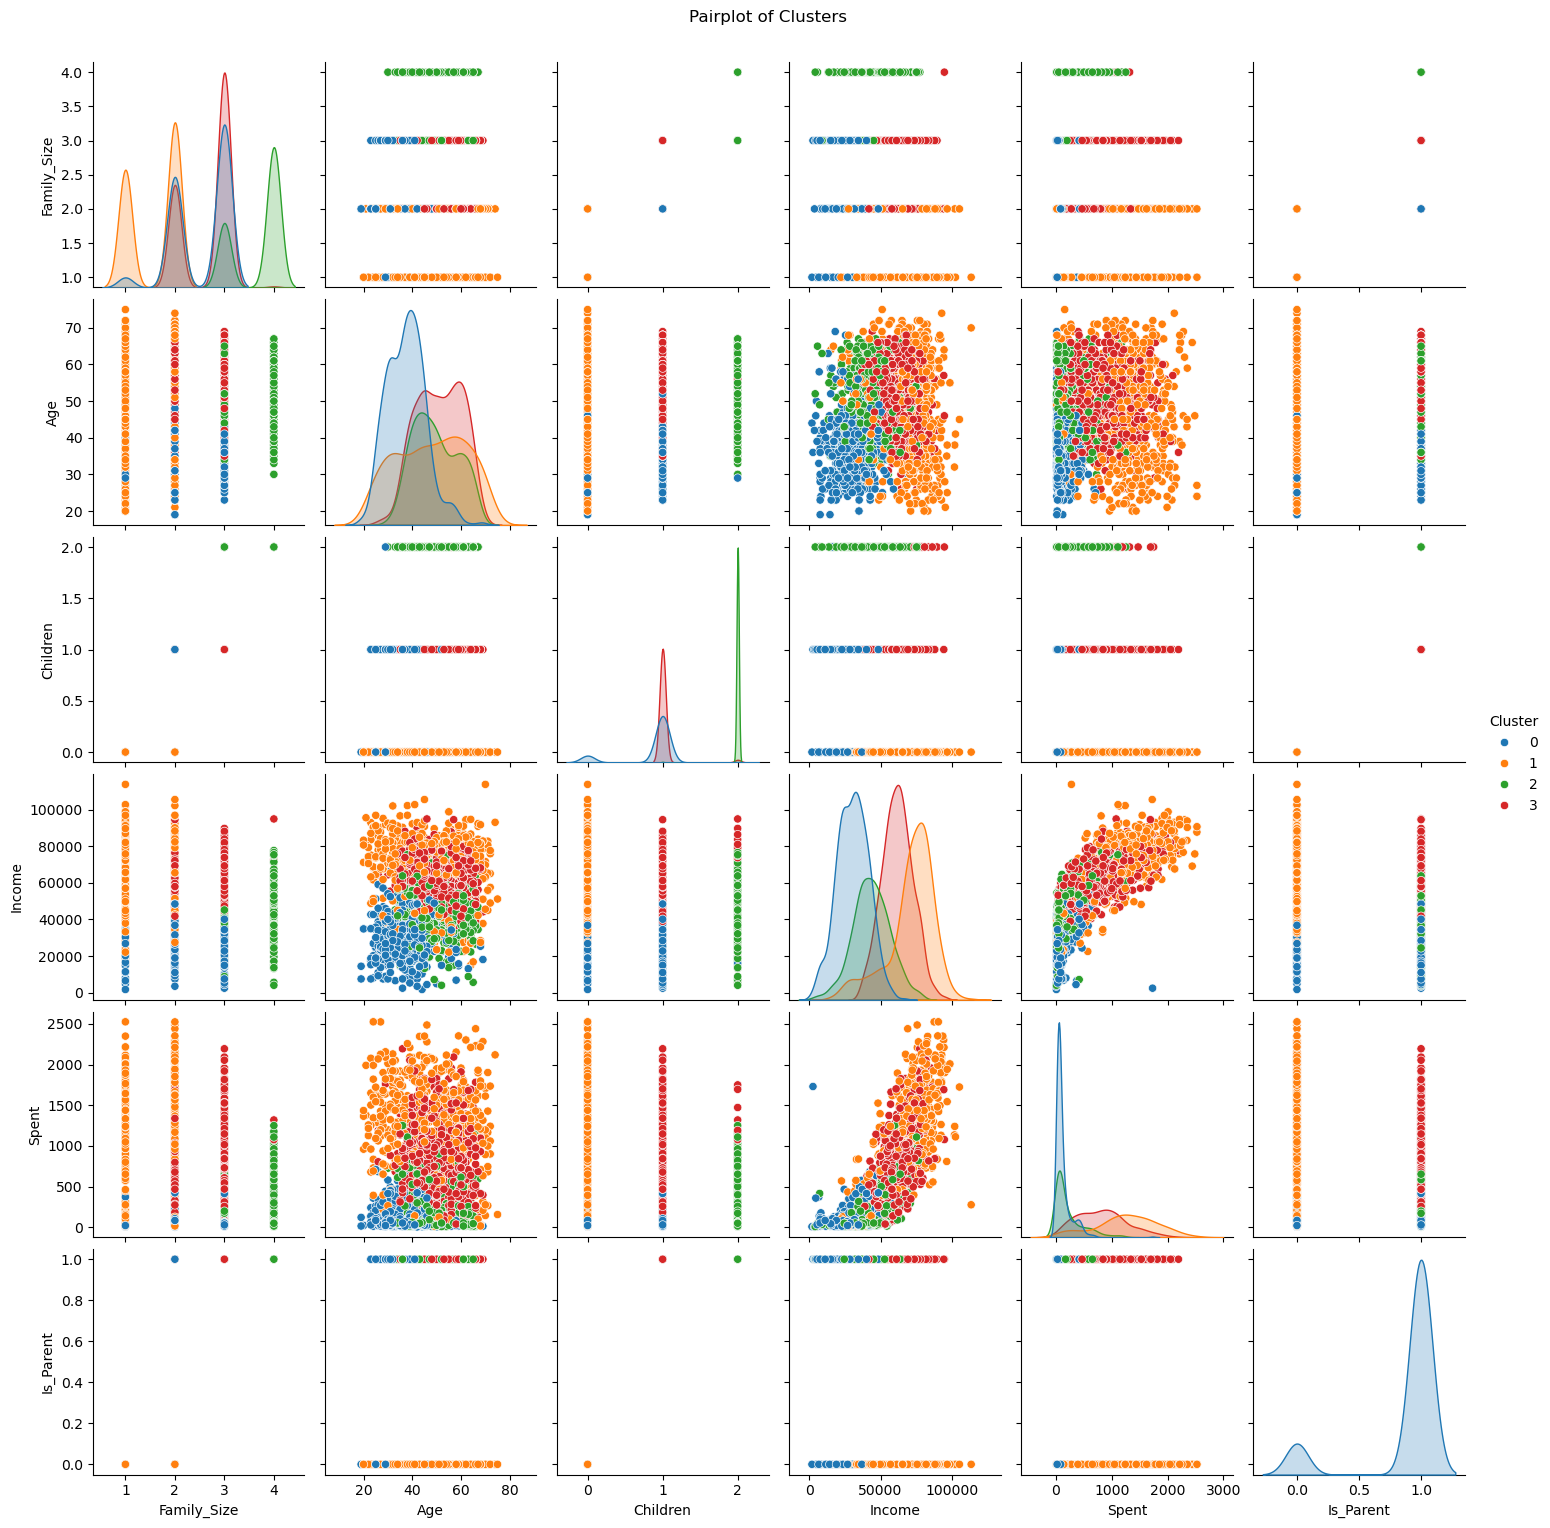

In [ ]:
sns.pairplot(data, hue='Cluster', diag_kind='kde', palette='tab10')
plt.suptitle('Pairplot of Clusters', y=1.02)
plt.show()

In [ ]:
# Step 4: Save the KMeans model
kmeans_model_filename = r'C:\\Users\\lenovo 2020\\OneDrive\\Desktop\\Khushi Chadha- BCA min-major project\\models\\cust_segmen_model.pkl'
with open(kmeans_model_filename, 'wb') as f:
    pickle.dump(kmeans, f)

# Step 5: Save the scaler
cluster_scaler_filename = r'C:\\Users\\lenovo 2020\\OneDrive\\Desktop\\Khushi Chadha- BCA min-major project\\models\\cust_segmen_scaler.pkl'
with open(cluster_scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print("KMeans clustering model and scaler saved successfully.")

KMeans clustering model and scaler saved successfully.


About Cluster 0:

The majority of these people are parents
At max have 3 members in the family
They majorly have one kid and typically not tennagers
Relatively younger
About Cluster 1:

Definitely a parent
At max have 4 members in the family and at least 2
Most have a teeanger in home
Single parents are a subset of this group
Relatively older
About Cluster 2:

Definitely not a parent
At max are only 2 members in the family.
A slight majority of couples over single people
Span all ages
high income and high spending
About Cluster 3:

Definitely a parent
At max have 5 members in the family and at least 2
Majority of them have a teenager at home
Relatively older